In [19]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

FILE_PATH = "data/all_data_with_identities.csv"

def load_data(file_path=FILE_PATH):
    df = pd.read_csv(file_path)
    return df



# Analyse des longueurs et de la distribution de `toxicity`

Ce notebook calcule les statistiques de longueur des textes, compare les longueurs entre textes toxiques et non-toxiques, examine l'équilibre du dataset et commente la distribution continue de la colonne `toxicity`.

In [29]:
# Charger les données et préparer la colonne de longueur
df = load_data()
df['comment_text'] = df['comment_text'].fillna('')
df['text_length'] = df['comment_text'].str.len()
threshold = 0.5
df['is_toxic'] = (df['toxicity'] >= threshold).astype(int)

#keep only id, comment_text, male, female, homosexual_gay_or_lesbian, black, white, na_gender, na_orientation, na_race, toxicity
cols_to_keep = ['id', 'comment_text', 'male', 'female', 'homosexual_gay_or_lesbian', 'black', 'white', 'na_gender', 'na_orientation', 'na_race', 'text_length', 'toxicity','is_toxic']
df = df[cols_to_keep].copy()



print('Shape:', df.shape)



Shape: (448000, 13)


In [30]:
df.head(10)

,id,comment_text,male,female,homosexual_gay_or_lesbian,black,white,na_gender,na_orientation,na_race,text_length,toxicity,is_toxic
0,627762,OH yes - Were those evil Christian Missionarie...,0.0,0.0,0.0,0.0,0.00,1,1,1,253,0.800000,1
1,5892815,Why is this black racist crap still on the G&M...,0.0,0.0,0.0,1.0,0.75,1,1,0,688,0.757143,1
2,416437,even up here.......BLACKS!,0.0,0.0,0.0,1.0,0.00,1,1,0,26,0.688525,1
3,5137126,Blame men. There's always an excuse to blame ...,1.0,1.0,0.0,0.0,0.00,0,1,1,76,0.545455,1
4,855753,And the woman exposing herself saying grab thi...,0.0,1.0,0.0,0.0,0.00,0,1,1,165,0.728571,1
5,379144,You have no business making any comments on th...,0.0,0.0,0.0,0.0,0.00,1,1,1,484,0.594595,1
6,377096,"""Let's get the black folks and the white folks...",0.0,0.0,0.0,1.0,1.00,1,1,0,71,0.736842,1
7,641883,I guess the issue is people not willing to put...,0.0,0.0,0.0,0.0,0.00,1,1,1,135,0.764706,1
8,5218990,"JackJohnson5:\n""And they say Trump supporters ...",0.0,0.0,0.0,0.0,0.00,1,1,1,270,1.000000,1
9,5483824,Trump could accidently push a button and Canad...,0.0,0.0,0.0,0.0,0.00,1,1,1,153,0.421875,0


In [31]:
# Statistiques descriptives des longueurs (min, max, mean, median, percentiles)
length_stats = df['text_length'].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.9,0.95,0.99])
length_stats_df = length_stats.to_frame(name='value')
length_stats_df.loc['variance'] = df['text_length'].var()
length_stats_df

,value
count,448000.000000
mean,351.742944
std,289.323733
min,0.000000
1%,15.000000
5%,39.000000
25%,121.000000
50%,257.000000
75%,512.000000
90%,872.000000


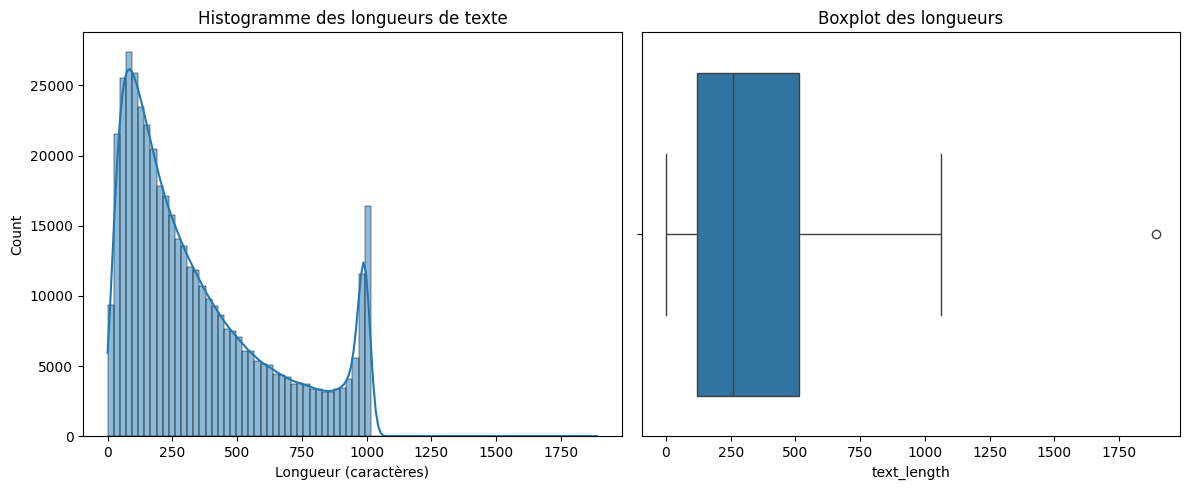

In [32]:
# Histogramme et boxplot de la distribution des longueurs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['text_length'], bins=80, kde=True)
plt.title('Histogramme des longueurs de texte')
plt.xlabel('Longueur (caractères)')
plt.subplot(1,2,2)
sns.boxplot(x=df['text_length'])
plt.title('Boxplot des longueurs')
plt.tight_layout()
plt.show()

## Distribution des longueurs par classe toxique / non-toxique

On crée une classe binaire `is_toxic` en se basant sur un seuil de `toxicity >= 0.5`. Vous pouvez ajuster le seuil si nécessaire.

In [33]:
# Définir la classe binaire (seuil 0.5) et vérifier l'équilibre

counts = df['is_toxic'].value_counts().sort_index()
percent = df['is_toxic'].value_counts(normalize=True).sort_index() * 100
balance_df = pd.DataFrame({'count': counts, 'percent': percent})
balance_df.index = ['non_toxic','toxic']
balance_df

,count,percent
non_toxic,397206,88.662054
toxic,50794,11.337946


### Équilibre du jeu de données
Le dataset présente un **déséquilibre de classe important** :
* **Non-toxiques :** 88,66 %
* **Toxiques :** 11,33 %

Ce déséquilibre (ratio d'environ 1 pour 8) implique que l'Accuracy ne sera pas un indicateur de performance pertinent. Un modèle "naïf" prédisant systématiquement la classe majoritaire obtiendrait un score élevé sans pour autant détecter la toxicité. Il sera crucial de surveiller le **F1-Score** ou l'**AUC-ROC** lors de l'entraînement.

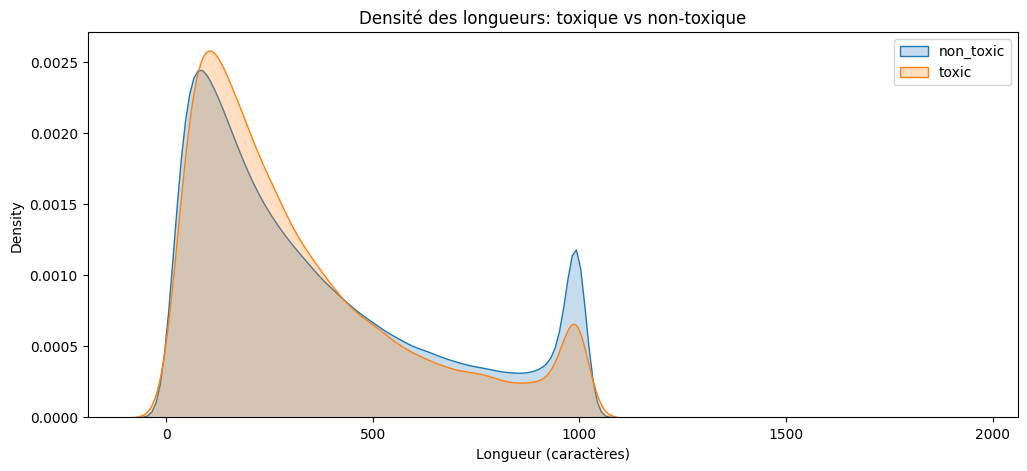

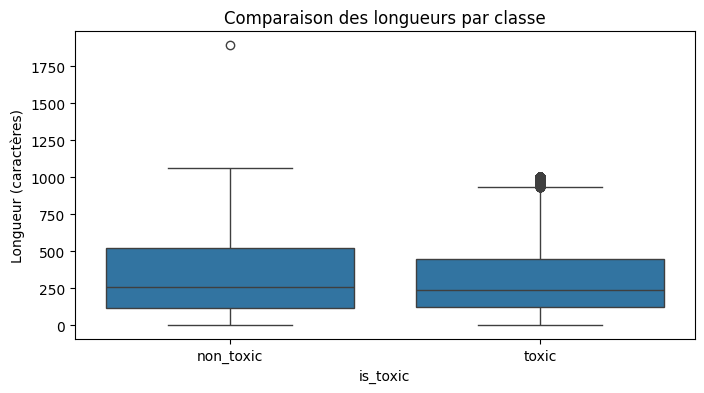

In [34]:
# Distribution des longueurs pour les deux classes
plt.figure(figsize=(12,5))
sns.kdeplot(df.loc[df['is_toxic']==0,'text_length'], label='non_toxic', fill=True, bw_adjust=1)
sns.kdeplot(df.loc[df['is_toxic']==1,'text_length'], label='toxic', fill=True, bw_adjust=1)
plt.legend()
plt.xlabel('Longueur (caractères)')
plt.title('Densité des longueurs: toxique vs non-toxique')
plt.show()
# Boxplot comparatif
plt.figure(figsize=(8,4))
sns.boxplot(x='is_toxic', y='text_length', data=df)
plt.xticks([0,1], ['non_toxic','toxic'])
plt.ylabel('Longueur (caractères)')
plt.title('Comparaison des longueurs par classe')
plt.show()

### Analyse des longueurs (Toxique vs Non-Toxique)
L'observation de la densité et des Boxplots permet de dégager plusieurs points clés :

* **Similarité de structure :** Les distributions des deux classes se superposent largement. La majorité des textes sont courts, avec un pic de fréquence entre **0 et 250 caractères**.
* **Effet de seuil :** On note un second pic marqué aux alentours de **1000 caractères**. Cela suggère une contrainte technique (limite de caractères de la plateforme source) plutôt qu'un comportement naturel d'écriture.
* **Comportement de la classe toxique :** La densité des commentaires toxiques est légèrement plus élevée pour les messages très courts. À l'inverse, les commentaires non-toxiques présentent davantage de valeurs extrêmes (outliers) au-delà de 1000 caractères, suggérant que les messages très longs sont plus rarement classés comme toxiques.

## Commentaires automatiques sur l'équilibre et la distribution de `toxicity`

,value
n_samples,448000.000000
n_missing_comments,0.000000
tox_mean,0.140029
tox_median,0.000000
tox_std,0.218396
tox_skew,1.641299
tox_kurtosis,1.955947
tox_min,0.000000
tox_max,1.000000


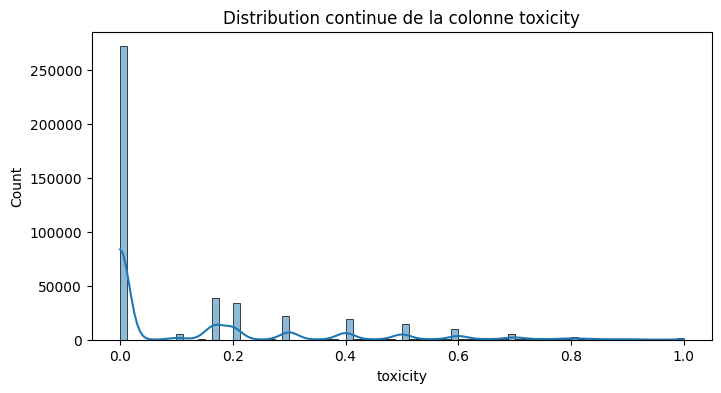

Commentaires:
- Echantillons: 448000
- Moyenne toxicity: 0.1400, médiane: 0.0000, écart-type: 0.2184
- La distribution de `toxicity` est fortement asymétrique (skewness > 1).
Equilibre (seuil 0.5) :
            count    percent
non_toxic  397206  88.662054
toxic       50794  11.337946


In [35]:
# Observations automatiques
from scipy.stats import skew, kurtosis
tox = df['toxicity'].dropna()
obs = {}
obs['n_samples'] = len(df)
obs['n_missing_comments'] = df['comment_text'].isna().sum()
obs['tox_mean'] = tox.mean()
obs['tox_median'] = tox.median()
obs['tox_std'] = tox.std()
obs['tox_skew'] = skew(tox) if len(tox)>0 else float('nan')
obs['tox_kurtosis'] = kurtosis(tox) if len(tox)>0 else float('nan')
obs['tox_min'] = tox.min()
obs['tox_max'] = tox.max()
obs_df = pd.Series(obs).to_frame('value')
display(obs_df)
# Histogramme de la colonne toxicity
plt.figure(figsize=(8,4))
sns.histplot(tox, bins=80, kde=True)
plt.title('Distribution continue de la colonne toxicity')
plt.xlabel('toxicity')
plt.show()
# Quelques commentaires textuels basés sur chiffres
print('Commentaires:')
print(f"- Echantillons: {obs['n_samples']}")
print(f"- Moyenne toxicity: {obs['tox_mean']:.4f}, médiane: {obs['tox_median']:.4f}, écart-type: {obs['tox_std']:.4f}")
if abs(obs['tox_skew'])>1:
    print('- La distribution de `toxicity` est fortement asymétrique (skewness > 1).')
elif abs(obs['tox_skew'])>0.5:
    print('- La distribution de `toxicity` montre une asymétrie modérée.')
else:
    print('- La distribution de `toxicity` est proche de la symétrie.')
# Équilibre selon seuil
print('Equilibre (seuil 0.5) :')
print(balance_df.to_string())

### Distribution de la variable cible (Toxicity)
La variable `toxicity` étant un score continu entre 0 et 1, sa distribution révèle la nature du processus d'annotation :

* **Prédominance du neutre :** Une immense majorité des données se concentre à la valeur **0.0**, confirmant la rareté relative des contenus problématiques.
* **Nature discrète des scores :** La distribution présente des "pics" réguliers (ex: 0.16, 0.2, 0.33, 0.5). Cela s'explique par le calcul du score : il s'agit du ratio d'annotateurs ayant jugé le texte toxique (par exemple, 1 annotateur sur 6 donne 0.166).
* **Concentration autour du seuil :** Très peu de commentaires font l'unanimité (score de 1.0). La plupart des contenus classés comme toxiques se situent dans la zone **[0.5 - 0.7]**, ce qui souligne la subjectivité inhérente à la détection de la toxicité.